In [1]:
!pip install memory_profiler networkx

In [32]:
# Core imports
import itertools
import time
import math
import heapq
from functools import lru_cache
import random

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline


In [33]:
# ---------------------------
# Problem definition
# ---------------------------
nodes = ['Warehouse', 'C1', 'C2', 'C3']   # Warehouse == Depot
weights_matrix = [
    [0, 4, 8, 6],
    [4, 0, 5, 7],
    [8, 5, 0, 3],
    [6, 7, 3, 0]
]

packages = {
    'C1': {'price': 50, 'window': (9, 12), 'mass': 10},
    'C2': {'price': 60, 'window': (10, 13), 'mass': 20},
    'C3': {'price': 40, 'window': (11, 14), 'mass': 15}
}

truck_capacity = 30
M = len(nodes)

def id_of(name): return nodes.index(name)
def travel(a, b): return weights_matrix[a][b]


In [34]:
# ---------------------------
# Exact tour cost by recursion
# ---------------------------
@lru_cache(maxsize=None)
def rec_tour_cost(curr_idx, visited_bitmask):
    ALL_MASK = (1 << M) - 1
    if visited_bitmask == ALL_MASK:
        return travel(curr_idx, 0)
    best_val = float('inf')
    for nxt in range(M):
        if not (visited_bitmask & (1 << nxt)):
            cand = travel(curr_idx, nxt) + rec_tour_cost(nxt, visited_bitmask | (1 << nxt))
            if cand < best_val:
                best_val = cand
    return best_val

start_mask = 1 << 0
min_cost_exact = rec_tour_cost(0, start_mask)
print("Recursive exact tour cost:", min_cost_exact)


Recursive exact tour cost: 18


In [35]:
# ---------------------------
# Greedy packing: price / mass
# ---------------------------
items_list = [(k, v['price'], v['mass'], v['window']) for k, v in packages.items()]
items_sorted = sorted(items_list, key=lambda x: x[1]/x[2], reverse=True)

remaining = truck_capacity
picked = []
for name, price, mass, win in items_sorted:
    if mass <= remaining:
        picked.append((name, price, mass))
        remaining -= mass

picked_names = [p[0] for p in picked]
picked_value = sum(p[1] for p in picked)
picked_weight = sum(p[2] for p in picked)
print("Greedy picked:", picked_names, "value:", picked_value, "weight:", picked_weight)


Greedy picked: ['C1', 'C2'] value: 110 weight: 30


In [36]:
# ---------------------------
# Bitmask DP: earliest arrival times for subsets
# ---------------------------
cust_idxs = [id_of(c) for c in packages.keys()]
pkg_by_idx = {id_of(c): packages[c] for c in packages}

def earliest_arrivals_for(subset_indices):
    """
    Compute earliest feasible arrival times for each (mask, last) state
    where mask indexes positions in subset_indices.
    """
    q = len(subset_indices)
    pos_of = {subset_indices[i]: i for i in range(q)}
    dp_map = {}   # (mask, last_idx) -> earliest arrival time

    # seed states: go from hub to each candidate
    for real_idx in subset_indices:
        t = travel(0, real_idx)
        e, l = pkg_by_idx[real_idx]['window']
        if t <= l:
            dp_map[(1 << pos_of[real_idx], real_idx)] = max(t, e)

    # expand
    for mask in range(1, 1<<q):
        for last_pos in range(q):
            if not (mask & (1 << last_pos)):
                continue
            last_real = subset_indices[last_pos]
            key = (mask, last_real)
            if key not in dp_map:
                continue
            cur_time = dp_map[key]
            for nxt_pos in range(q):
                if mask & (1 << nxt_pos):
                    continue
                nxt_real = subset_indices[nxt_pos]
                arr = cur_time + travel(last_real, nxt_real)
                e, l = pkg_by_idx[nxt_real]['window']
                if arr <= l:
                    dp_map[(mask | (1 << nxt_pos), nxt_real)] = min(dp_map.get((mask | (1 << nxt_pos), nxt_real), float('inf')), max(arr, e))
    return dp_map

# compute DP for all customers and for greedy-picked subset
dp_all_states = earliest_arrivals_for(cust_idxs)
picked_idxs = [id_of(n) for n in picked_names]
dp_picked_states = earliest_arrivals_for(picked_idxs) if picked_idxs else {}

# Convert DP states into readable feasible-route summaries
def states_to_summary(dp_map, subset_indices):
    q = len(subset_indices)
    summaries = []
    for (mask, last), atime in dp_map.items():
        visited = [subset_indices[i] for i in range(q) if mask & (1<<i)]
        visited_names = [nodes[idx] for idx in visited]
        total_val = sum(packages[nodes[idx]]['price'] for idx in visited)
        total_mass = sum(packages[nodes[idx]]['mass'] for idx in visited)
        summaries.append({'mask': mask, 'last': last, 'arrival': atime, 'visited': visited_names, 'value': total_val, 'mass': total_mass})
    return summaries

feasible_all_summaries = states_to_summary(dp_all_states, cust_idxs)
feasible_picked_summaries = states_to_summary(dp_picked_states, picked_idxs)
print("Feasible state count (all):", len(feasible_all_summaries))
print("Feasible state count (picked):", len(feasible_picked_summaries))


Feasible state count (all): 4
Feasible state count (picked): 2


In [37]:
# ---------------------------
# select best feasible summary under capacity constraint
# ---------------------------
def pick_best(summaries):
    best = None
    for s in summaries:
        if s['mass'] <= truck_capacity:
            if (best is None) or (s['value'] > best['value']) or (s['value']==best['value'] and s['arrival'] < best['arrival']):
                best = s
    return best

best_from_all = pick_best(feasible_all_summaries)
best_from_picked = pick_best(feasible_picked_summaries)
print("Best from all:", best_from_all)
print("Best from greedy-picked:", best_from_picked)


Best from all: {'mask': 2, 'last': 2, 'arrival': 10, 'visited': ['C2'], 'value': 60, 'mass': 20}
Best from greedy-picked: {'mask': 2, 'last': 2, 'arrival': 10, 'visited': ['C2'], 'value': 60, 'mass': 20}


In [38]:
# ---------------------------
# brute-force check all subsets to maximize delivered price under capacity & windows
# ---------------------------
def brute_best_subset():
    names = list(packages.keys())
    best = {'subset': [], 'value': 0, 'mass': 0, 'order': None}
    for r in range(1, len(names)+1):
        for comb in itertools.combinations(names, r):
            mass_sum = sum(packages[c]['mass'] for c in comb)
            if mass_sum > truck_capacity:
                continue
            # find any order that meets windows
            feasible_order = None
            for perm in itertools.permutations(comb):
                t = 0
                cur = 0
                ok = True
                arrivals = []
                for p in perm:
                    j = id_of(p)
                    t += travel(cur, j)
                    e,l = packages[p]['window']
                    if t > l:
                        ok = False
                        break
                    t = max(t, e)
                    arrivals.append(t)
                    cur = j
                if ok:
                    feasible_order = (perm, arrivals)
                    break
            if feasible_order:
                val = sum(packages[c]['price'] for c in comb)
                if val > best['value']:
                    best = {'subset': list(comb), 'value': val, 'mass': mass_sum, 'order': feasible_order}
    return best

exact_best = brute_best_subset()
print("Exact best subset (brute):", exact_best)


Exact best subset (brute): {'subset': ['C2'], 'value': 60, 'mass': 20, 'order': (('C2',), [10])}


In [39]:
# ---------------------------
# Graph algorithms: Dijkstra, Prim, Kruskal
# ---------------------------
def dijkstra_shortest(start):
    dist = [math.inf]*M
    dist[start] = 0
    parent = [None]*M
    pq = [(0, start)]
    while pq:
        d,u = heapq.heappop(pq)
        if d != dist[u]:
            continue
        for v in range(M):
            if u == v: continue
            newd = d + weights_matrix[u][v]
            if newd < dist[v]:
                dist[v] = newd
                parent[v] = u
                heapq.heappush(pq, (newd, v))
    return dist, parent

distances_from_hub, preds = dijkstra_shortest(0)
print("Distances from Warehouse:", distances_from_hub)

# Prim's MST (alternate code style)
def prim_tree():
    selected = [False]*M
    mincost = [math.inf]*M
    parent = [-1]*M
    mincost[0] = 0
    for _ in range(M):
        u = min((cost, idx) for idx, cost in enumerate(mincost) if not selected[idx])[1]
        selected[u] = True
        for v in range(M):
            if not selected[v] and weights_matrix[u][v] < mincost[v]:
                mincost[v] = weights_matrix[u][v]
                parent[v] = u
    edges = [(parent[v], v, weights_matrix[parent[v]][v]) for v in range(1, M)]
    return edges, sum(e[2] for e in edges)

prim_edges, prim_total = prim_tree()
print("Prim edges:", prim_edges, "total:", prim_total)

# Kruskal's MST using union-find
class UF:
    def __init__(self, n):
        self.p = list(range(n))
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]
            x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return False
        self.p[rb] = ra
        return True

def kruskal_tree():
    edges = []
    for i in range(M):
        for j in range(i+1, M):
            edges.append((weights_matrix[i][j], i, j))
    edges.sort()
    uf = UF(M)
    mst = []
    total = 0
    for w,i,j in edges:
        if uf.union(i,j):
            mst.append((i,j,w))
            total += w
    return mst, total

kruskal_edges, kruskal_total = kruskal_tree()
print("Kruskal edges:", kruskal_edges, "total:", kruskal_total)


Distances from Warehouse: [0, 4, 8, 6]
Prim edges: [(0, 1, 4), (1, 2, 5), (2, 3, 3)] total: 12
Kruskal edges: [(2, 3, 3), (0, 1, 4), (1, 2, 5)] total: 12


In [40]:
# ---------------------------
# TSP: backtracking + Held-Karp
# ---------------------------
def tsp_backtrack(city_list, weight_mat):
    nloc = len(city_list)
    best_route = None
    best_cost = float('inf')

    def backtrack(curr, visited_mask, cost_so_far, path):
        nonlocal best_cost, best_route
        if visited_mask == (1<<nloc)-1:
            total_cost = cost_so_far + weight_mat[curr][0]
            if total_cost < best_cost:
                best_cost = total_cost
                best_route = path + [0]
            return
        for nxt in range(nloc):
            if visited_mask & (1<<nxt): continue
            backtrack(nxt, visited_mask | (1<<nxt), cost_so_far + weight_mat[curr][nxt], path + [nxt])

    backtrack(0, 1<<0, 0, [0])
    route_names = [city_list[i] for i in best_route]
    return route_names, best_cost

def held_karp_cost(weight_mat):
    k = len(weight_mat)
    N = 1<<k
    dp = [[math.inf]*k for _ in range(N)]
    dp[1][0] = 0
    for mask in range(N):
        for u in range(k):
            if not (mask & (1<<u)): continue
            for v in range(k):
                if mask & (1<<v): continue
                dp[mask | (1<<v)][v] = min(dp[mask | (1<<v)][v], dp[mask][u] + weight_mat[u][v])
    full = (1<<k)-1
    res = min(dp[full][u] + weight_mat[u][0] for u in range(1,k))
    return res

tsp_route_bt, tsp_cost_bt = tsp_backtrack(nodes, weights_matrix)
hk_cost = held_karp_cost(weights_matrix)
print("TSP backtrack route:", tsp_route_bt, "cost:", tsp_cost_bt)
print("Held-Karp cost:", hk_cost)


TSP backtrack route: ['Warehouse', 'C1', 'C2', 'C3', 'Warehouse'] cost: 18
Held-Karp cost: 18


In [41]:
# ---------------------------
# Profile TSP brute-force for small k
# ---------------------------
def profile_bruteforce(max_k=6):
    results = []
    base = weights_matrix
    for k in range(3, max_k+1):
        # build small weight matrix for k nodes (Hub + k-1 others)
        mat = [[0]*k for _ in range(k)]
        for i in range(k):
            for j in range(k):
                if i < len(base) and j < len(base):
                    mat[i][j] = base[i][j]
                else:
                    mat[i][j] = abs(i-j) + 1
        names = ['Warehouse'] + [f'X{i}' for i in range(1, k)]
        t0 = time.time()
        route, cost = tsp_backtrack(names, mat)
        elapsed = time.time() - t0
        results.append({'nodes': k, 'time_s': elapsed, 'cost': cost, 'route': route})
    return results

tsp_stats = profile_bruteforce(6)
for r in tsp_stats:
    print(r)


{'nodes': 3, 'time_s': 1.0728836059570312e-05, 'cost': 17, 'route': ['Warehouse', 'X1', 'X2', 'Warehouse']}
{'nodes': 4, 'time_s': 1.1682510375976562e-05, 'cost': 18, 'route': ['Warehouse', 'X1', 'X2', 'X3', 'Warehouse']}
{'nodes': 5, 'time_s': 6.532669067382812e-05, 'cost': 19, 'route': ['Warehouse', 'X1', 'X2', 'X3', 'X4', 'Warehouse']}
{'nodes': 6, 'time_s': 0.00017762184143066406, 'cost': 22, 'route': ['Warehouse', 'X1', 'X2', 'X3', 'X4', 'X5', 'Warehouse']}


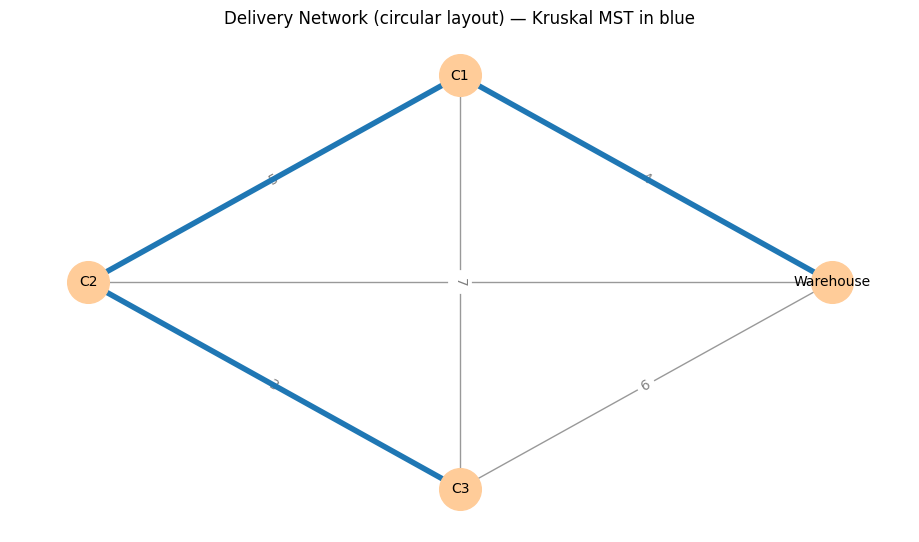

In [42]:
# ---------------------------
# Visual: network graph + Kruskal MST highlighted
# ---------------------------
G = nx.Graph()
G.add_nodes_from(nodes)
for i in range(M):
    for j in range(i+1, M):
        G.add_edge(nodes[i], nodes[j], weight=weights_matrix[i][j])

pos = nx.circular_layout(G)   # different layout

plt.figure(figsize=(9,5))
nx.draw(G, pos, with_labels=True, node_size=900, font_size=10, node_color='#ffcc99', edge_color='#999999')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray')

# kruskal edges thickened and colored
kr_edges_draw = [(nodes[i], nodes[j]) for (i,j,w) in kruskal_edges]
nx.draw_networkx_edges(G, pos, edgelist=kr_edges_draw, width=4, edge_color='#1f77b4')

plt.title("Delivery Network (circular layout) — Kruskal MST in blue")
plt.axis('off')
plt.show()


In [43]:
# ---------------------------
# Table and plots for packages
# ---------------------------
df_pkg = pd.DataFrame([
    {'Customer': k, 'Price': packages[k]['price'], 'Mass': packages[k]['mass'],
     'Price/Mass': packages[k]['price']/packages[k]['mass']} for k in packages
])

display(df_pkg)

,Customer,Price,Mass,Price/Mass
0,C1,50,10,5.000000
1,C2,60,20,3.000000
2,C3,40,15,2.666667


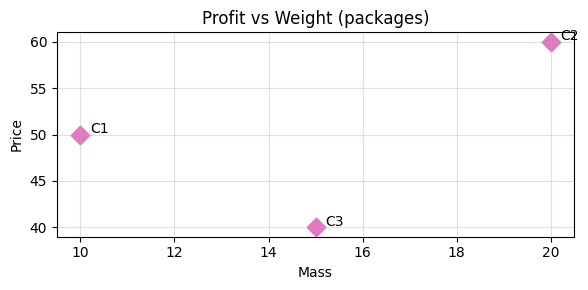

In [44]:
# Scatter Price vs Mass
plt.figure(figsize=(6,3))
plt.scatter(df_pkg['Mass'], df_pkg['Price'], s=90, marker='D', color='#e377c2')
for i,row in df_pkg.iterrows():
    plt.text(row['Mass']+0.2, row['Price']+0.2, row['Customer'])
plt.xlabel('Mass'); plt.ylabel('Price'); plt.title('Profit vs Weight (packages)')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

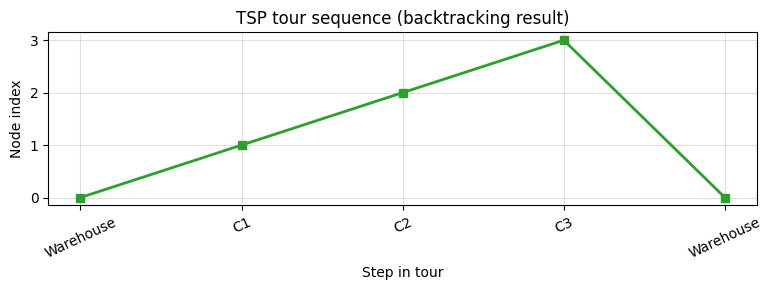

In [45]:
# ---------------------------
# Plot: TSP route sequence
# ---------------------------
route_labels = tsp_route_bt
route_idx_seq = [nodes.index(lbl) if lbl in nodes else nodes.index(lbl) for lbl in route_labels]

plt.figure(figsize=(8,3))
plt.plot(range(len(route_idx_seq)), route_idx_seq, marker='s', linestyle='-', linewidth=2, markersize=6, color='#2ca02c')
plt.xticks(range(len(route_idx_seq)), route_labels, rotation=25)
plt.xlabel("Step in tour")
plt.ylabel("Node index")
plt.title("TSP tour sequence (backtracking result)")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


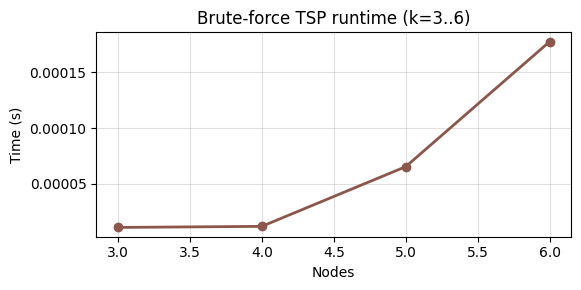

In [48]:
# profiling plot (TSP)
nodes_list = [r['nodes'] for r in tsp_stats]
times = [r['time_s'] for r in tsp_stats]
plt.figure(figsize=(6,3))
plt.plot(nodes_list, times, marker='o', color='#8c564b', linewidth=2)
plt.xlabel('Nodes'); plt.ylabel('Time (s)')
plt.title('Brute-force TSP runtime (k=3..6)')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

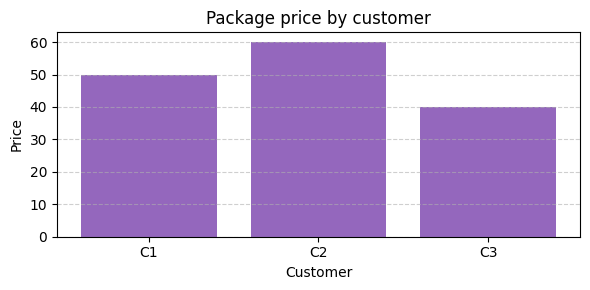

In [46]:
# Price bar
plt.figure(figsize=(6,3))
plt.bar(df_pkg['Customer'], df_pkg['Price'], color='#9467bd')
plt.xlabel('Customer'); plt.ylabel('Price'); plt.title('Package price by customer')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()